In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from pandas.plotting import parallel_coordinates

# Wczytanie danych
data = pd.read_csv('carbig.csv')
np.random.seed(int(3.8 * 2025))

# Zastąpienie NaN
columns = ['Acceleration', 'Displacement', 'Horsepower', 'Weight', 'MPG']
for col in columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Wybór kolumn
x = data[columns].values

# Dodanie losowego szumu
noise_multiplier = 1 + (np.random.rand(*x.shape) * 2 - 1) / 100
x = x * noise_multiplier

<ipython-input-1-f3f29d858dca>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
<ipython-input-1-f3f29d858dca>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df_x = pd.DataFrame(x, columns=columns)
descriptive_stats = df_x.describe().loc[['min', 'max', 'mean']]
descriptive_stats.loc['median'] = df_x.median()

unique_counts = df_x.nunique()
all_unique = unique_counts == len(df_x)

mode = df_x.mode()
for col in df_x.columns:
    if all_unique[col]:
        descriptive_stats.loc['mode', col] = np.nan
    else:
        descriptive_stats.loc['mode', col] = mode[col].iloc[0]
print(descriptive_stats)

        Acceleration  Displacement  Horsepower       Weight        MPG
min         7.951296     67.511576   45.949766  1599.222153   9.022294
max        25.011605    458.562755  228.526239  5134.525188  46.228956
mean       15.517602    194.770564  105.754828  2978.832303  23.315650
median     15.474616    149.656076   95.037314  2822.988676  22.392204
mode             NaN           NaN         NaN          NaN        NaN


Statystyki opisowe:
                  Rozstęp  Kwartyl pierwszy (Q1)  Kwartyl drugi (Q2)  \
Acceleration    17.060310              13.665012           15.474616   
Displacement   391.051179             104.121180          149.656076   
Horsepower     182.576473              75.707036           95.037314   
Weight        3535.303035            2230.552126         2822.988676   
MPG             37.206662              16.906480           22.392204   

              Kwartyl trzeci (Q3)  Rozstęp międzykwartylowy (IQR)  \
Acceleration            17.124958                        3.459945   
Displacement           299.426760                      195.305581   
Horsepower             131.570915                       55.863879   
Weight                3617.162062                     1386.609936   
MPG                     28.955745                       12.049265   

              Odchylenie ćwiartkowe                 Typowy obszar zmienności  
Acceleration               1.729973  1.80960416268156

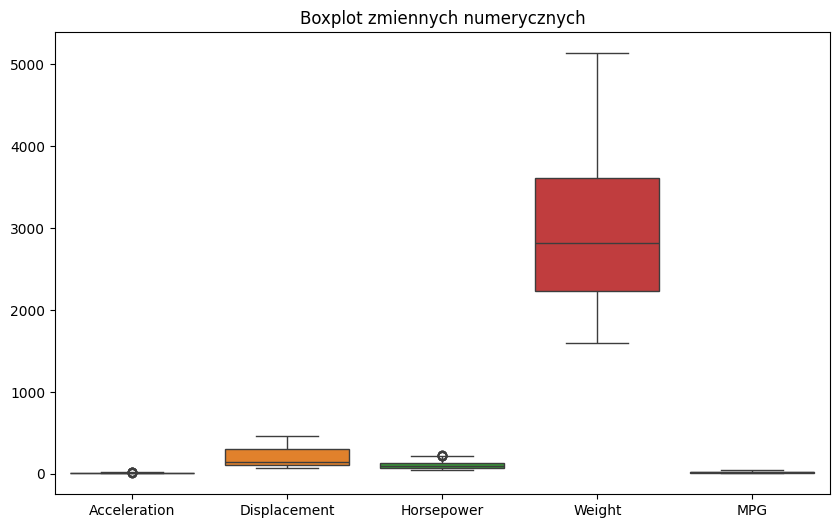

In [ ]:
results = pd.DataFrame({
    'Rozstęp': df_x.max() - df_x.min(),
    'Kwartyl pierwszy (Q1)': df_x.quantile(0.25),
    'Kwartyl drugi (Q2)': df_x.quantile(0.50),
    'Kwartyl trzeci (Q3)': df_x.quantile(0.75),
    'Rozstęp międzykwartylowy (IQR)': df_x.quantile(0.75) - df_x.quantile(0.25),
    'Odchylenie ćwiartkowe': (df_x.quantile(0.75) - df_x.quantile(0.25))/2,
    'Typowy obszar zmienności': (df_x.median() - df_x.quantile(0.25)).astype(str) +
    " ; " + (df_x.median() + df_x.quantile(0.25)).astype(str)
})

print("Statystyki opisowe:")
print(results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_x)
plt.title("Boxplot zmiennych numerycznych")
plt.show()

In [ ]:
rozrzut = pd.DataFrame(index=columns)
rozrzut['Odchylenie standardowe'] = df_x.std()
rozrzut['Wariancja'] = df_x.var()
rozrzut['Współczynnik zmienności (%)'] = (rozrzut['Odchylenie standardowe'] / df_x.mean()) * 100

print("Miary rozrzutu dla każdej zmiennej numerycznej:")
print(rozrzut)

Miary rozrzutu dla każdej zmiennej numerycznej:
              Odchylenie standardowe      Wariancja  \
Acceleration                2.803189       7.857867   
Displacement              104.858771   10995.361795   
Horsepower                 38.889055    1512.358609   
Weight                    848.499340  719951.129920   
MPG                         7.882789      62.138358   

              Współczynnik zmienności (%)  
Acceleration                    18.064574  
Displacement                    53.837073  
Horsepower                      36.772841  
Weight                          28.484294  
MPG                             33.809003  


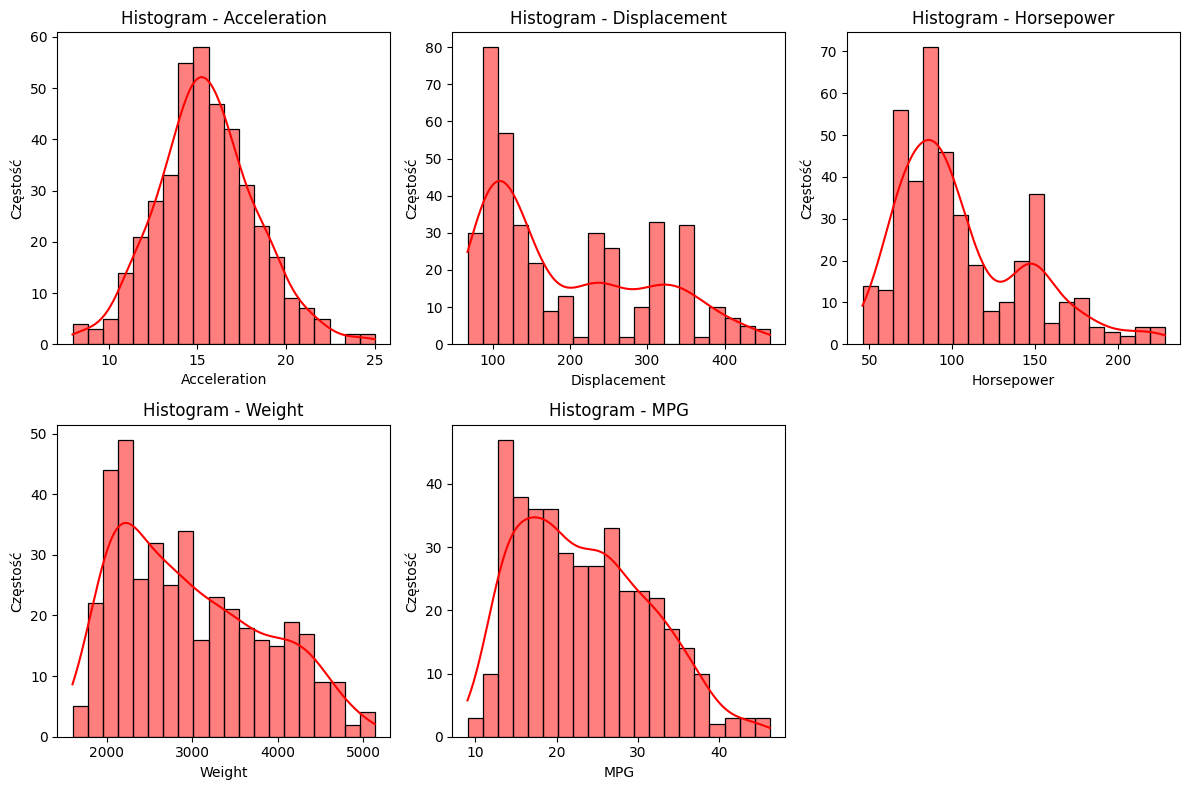

In [ ]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_x[col], bins=20, kde=True, color='red')
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Częstość')

plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame({
    'Kurtoza': df_x.kurtosis(),
    'Asymetria': df_x.skew()
})

print("Statystyki kurtozy i asymetrii:")
print(results)

Statystyki kurtozy i asymetrii:
               Kurtoza  Asymetria
Acceleration  0.402953   0.233809
Displacement -0.807774   0.695610
Horsepower    0.420389   0.986039
Weight       -0.817684   0.508819
MPG          -0.532852   0.469194


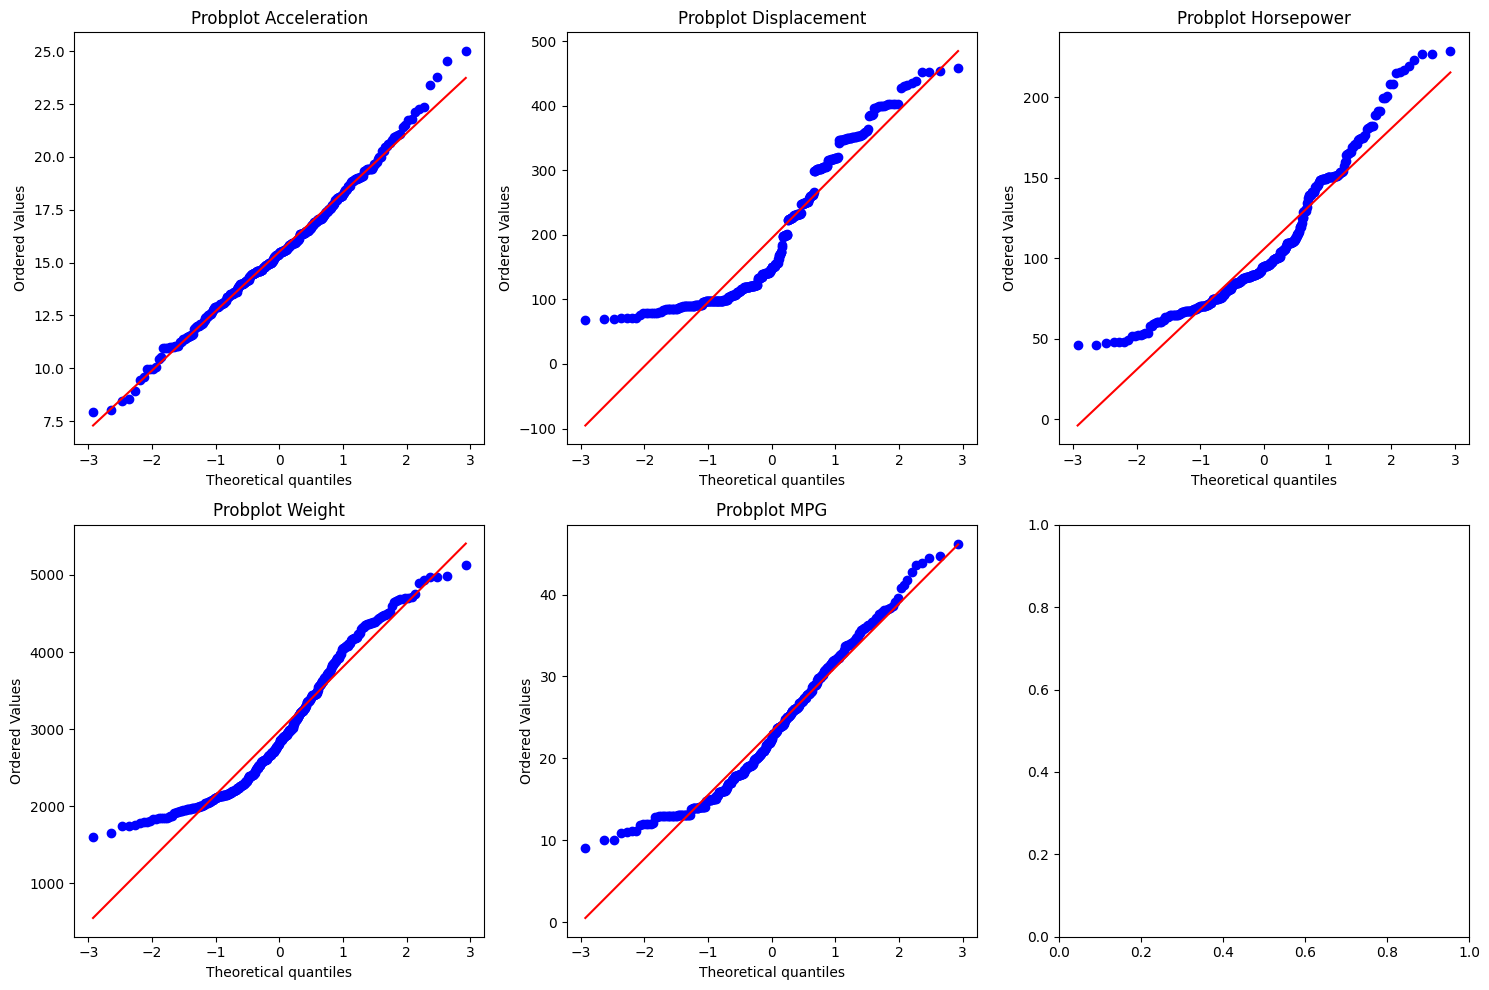

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(columns):
    stats.probplot(df_x[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Probplot {col}')
plt.tight_layout()
plt.show()

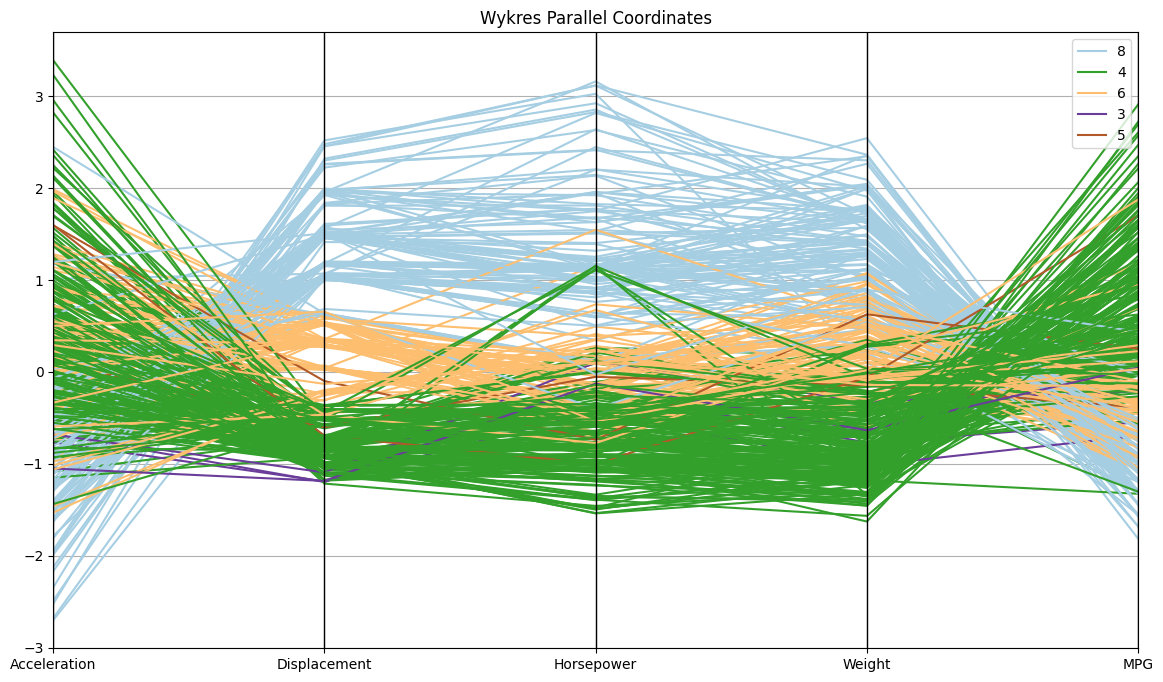

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

df_scaled = pd.DataFrame(x_scaled, columns=columns)

df_scaled['Cylinders'] = data['Cylinders']

plt.figure(figsize=(14, 8))
parallel_coordinates(df_scaled, 'Cylinders', colormap='Paired')
plt.title('Wykres Parallel Coordinates')
plt.show()

              Acceleration  Displacement  Horsepower    Weight       MPG
Acceleration      1.000000     -0.558426   -0.674948 -0.430690  0.424452
Displacement     -0.558426      1.000000    0.874240  0.931629 -0.793435
Horsepower       -0.674948      0.874240    1.000000  0.843876 -0.745291
Weight           -0.430690      0.931629    0.843876  1.000000 -0.822244
MPG               0.424452     -0.793435   -0.745291 -0.822244  1.000000


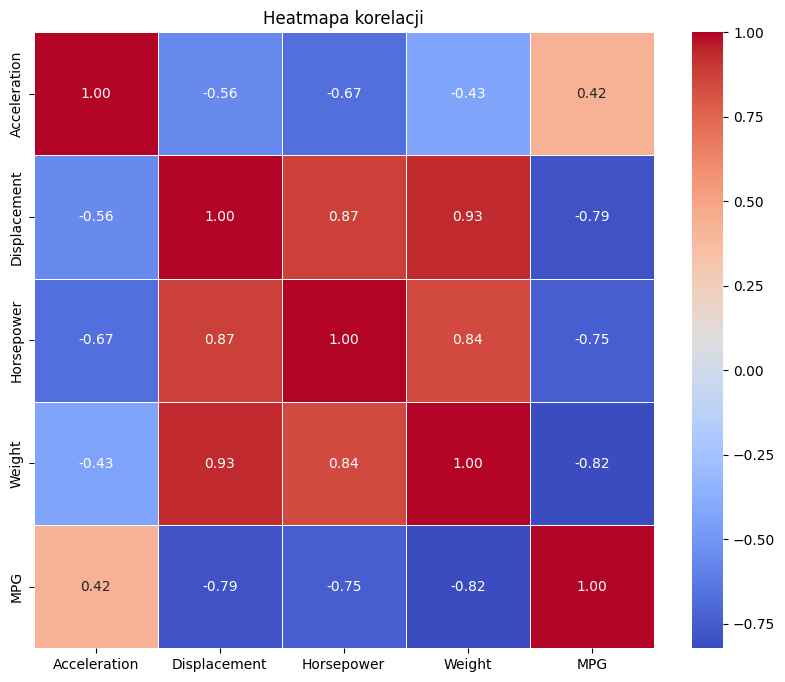

In [ ]:
print(df_x.corr())

plt.figure(figsize=(10, 8))
sns.heatmap(df_x.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmapa korelacji')
plt.show()

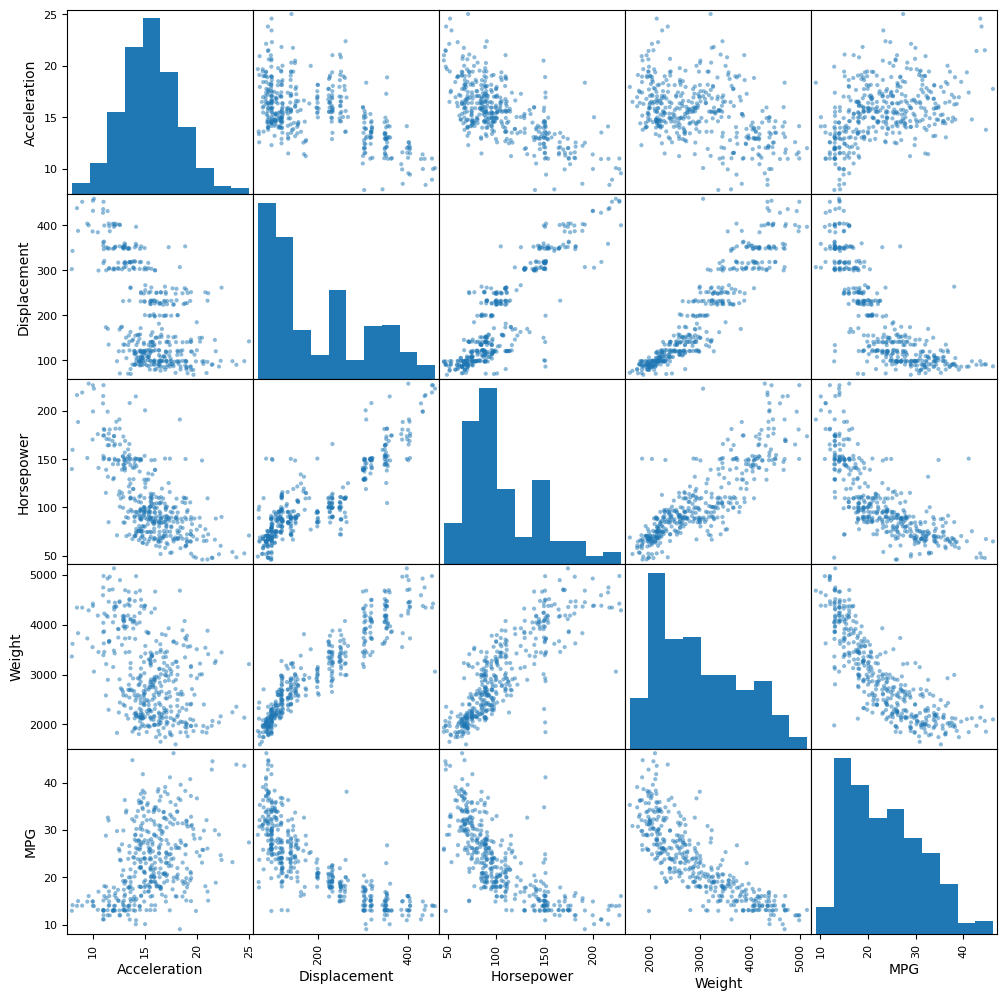

In [ ]:
scatter_matrix(df_x, figsize=(12, 12), diagonal='hist')
plt.show()


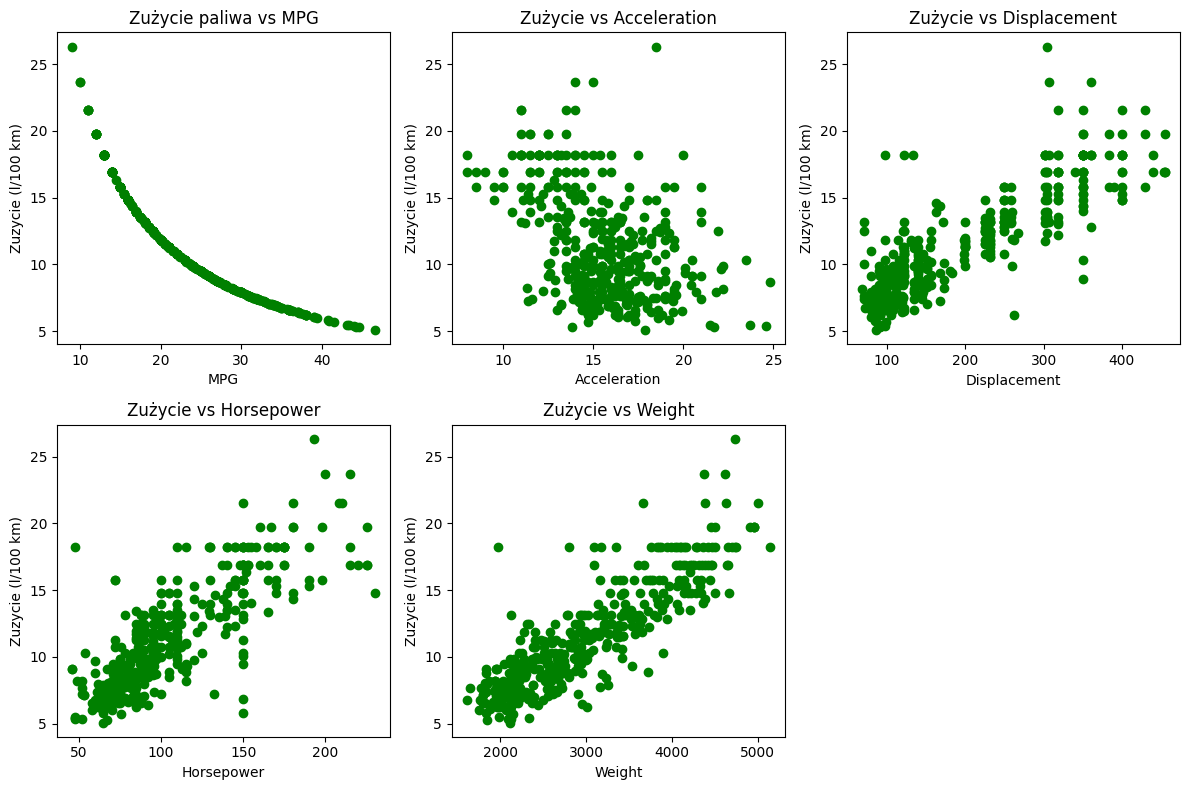

In [ ]:
data['Zuzycie'] = 3.79 / (data['MPG'] * 1.6) * 100

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].scatter(data['MPG'], data['Zuzycie'], c="green")
axes[0].set_xlabel("MPG")
axes[0].set_ylabel("Zuzycie (l/100 km)")
axes[0].set_title("Zużycie paliwa vs MPG")

features = ['Acceleration', 'Displacement', 'Horsepower', 'Weight']
for i, col in enumerate(features):
    axes[i+1].scatter(data[col], data['Zuzycie'], c="green")
    axes[i+1].set_xlabel(col)
    axes[i+1].set_ylabel("Zuzycie (l/100 km)")
    axes[i+1].set_title(f'Zużycie vs {col}')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [ ]:
cylinder_avg_consumption = data.groupby('Cylinders')['Zuzycie'].mean()
print(cylinder_avg_consumption)


Cylinders
3    11.659749
4     8.534553
5     9.167354
6    12.191568
8    16.436886
Name: Zuzycie, dtype: float64
